In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd "/app/"

/app


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [ ]:
%run env.py # not on aws, as only for the Mathis lab sessions
%run run.py connect

2026-01-08 13:23:17,974::INFO::settings.py::Setting loglevel to INFO
2026-01-08 13:23:17,975::INFO::settings.py::Setting stores to {}
2026-01-08 13:23:17,976::INFO::settings.py::Setting database.misc.schema_prefix to 
2026-01-08 13:23:17,977::INFO::settings.py::Setting database.misc.create_tables to True
2026-01-08 13:23:17,977::INFO::settings.py::Setting enable_python_native_blobs to True
2026-01-08 13:23:17,978::INFO::settings.py::Setting database.host to 128.178.51.167:3309
2026-01-08 13:23:17,979::INFO::settings.py::Setting database.user to root
2026-01-08 13:23:17,980::INFO::settings.py::Setting database.password to simple
2026-01-08 13:23:18,025::INFO::connection.py::Connected root@128.178.51.167:3309


Connecting root@128.178.51.167:3309


In [4]:
from vr4mice.schema.base_analysis import DataFrame
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from vr4mice.analysis import plotting
from base_schemas.schemas.exp import Session
from vr4mice.schema import base_analysis
from vr4mice.analysis.analysis import style
from vr4mice.schema.interpolated_trajectories import InterpolatedTrials
from vr4mice.schema.session_metrics import TrialMetrics
from vr4mice.analysis import analysis
from vr4mice.schema import dlc, inputs_videos
from vr4mice.analysis import utils
from vr4mice.analysis import regression

from statsmodels.stats.anova import AnovaRM
from scipy.stats import ttest_rel, ttest_ind
import scipy.stats as stats

style()

In [5]:
from vr4mice.schema.inputs_videos import AlignedVideoFrame

In [6]:
aligned_videos = pd.DataFrame((AlignedVideoFrame() & f'dataset = "Pheasant_2024-08-15_2"').fetch(as_dict=True)[0])

In [18]:
from vr4mice.schema.base_analysis import DataFrame
df = DataFrame().get_data(
    key={"dataset": "Pheasant_2024-08-15_2"},
    columns=[
        "dataset",
        "step_time",
        "reward",
        "mouse_in_left",
        "mouse_in_right",
        "trial",
        "aperture",
        "iti",
        "trial_left_choice",
        "trial_duration",
        "x",
        "y"
    ],
)

In [19]:
merged_df = pd.merge_asof(df, aligned_videos, left_on='step_time', right_on='step_time', direction="forward")

In [44]:
# First non ITI frame
merged_df[((merged_df["trial"]==5) | (merged_df["trial"]==10)) & (merged_df["iti"]==0)].groupby('trial').first()

,dataset_x,step_time,reward,x,y,iti,mouse_in_left,mouse_in_right,trial_duration,trial_left_choice,aperture,dataset_y,n_steps,step,frame_ids,interpol_func,decision
trial,,,,,,,,,,,,,,,,,
5,Pheasant_2024-08-15_2,34.005124,0.0,5.082441,-16.894557,0.0,0.0,0.0,1.44,0.0,4.3,Pheasant_2024-08-15_2,155185,2484,4074,b'\x80\x04\x95\xdd\x00\x00\x00\x00\x00\x00\x00...,0
10,Pheasant_2024-08-15_2,86.211743,0.0,3.780479,6.663716,0.0,0.0,0.0,0.70,1.0,12.0,Pheasant_2024-08-15_2,155185,6372,10339,b'\x80\x04\x95\xdd\x00\x00\x00\x00\x00\x00\x00...,0


In [ ]:
# Reward frames on trials 5 and 10
merged_df[((merged_df["trial"]==5) | (merged_df["trial"]==10)) & (merged_df["reward"]==1)]

,dataset_x,step_time,trial,reward,x,y,iti,mouse_in_left,mouse_in_right,trial_duration,trial_left_choice,aperture,dataset_y,n_steps,step,frame_ids,interpol_func,decision
1314,Pheasant_2024-08-15_2,35.467124,5,1.0,18.658589,23.214439,1.0,0.0,1.0,1.44,0.0,4.3,Pheasant_2024-08-15_2,155185,2594,4250,b'\x80\x04\x95\xdd\x00\x00\x00\x00\x00\x00\x00...,0
3884,Pheasant_2024-08-15_2,86.912785,10,1.0,-17.584477,17.375885,0.0,1.0,0.0,0.70,1.0,12.0,Pheasant_2024-08-15_2,155185,6425,10424,b'\x80\x04\x95\xdd\x00\x00\x00\x00\x00\x00\x00...,0


In [ ]:
from vr4mice.schema.decision import DecisionPoints
decision_points = pd.DataFrame((DecisionPoints()).fetch(as_dict=True)[0])

In [50]:
decision_points[decision_points["trial"].isin([5,10])]

,label_id,param_id,task_type,dataset,trial,proba_left,aperture,trial_left_choice,trial_rewarded,trial_length,x,y
3,1,1,dual_occl,Pheasant_2024-08-15_2,5,0.296237,4.3,0.0,1.0,0.49,-2.660132,14.639726
8,1,1,dual_occl,Pheasant_2024-08-15_2,10,0.734655,12.0,1.0,1.0,0.32,1.054981,13.299418


In [ ]:
merged_df['decision'] = 0

for _, row in decision_points.iterrows():
    # Filter merged_df for the current trial
    trial_mask = merged_df['trial'] == row['trial']
    df_trial = merged_df[trial_mask]
    
    # Calculate Euclidean distance: sqrt((x1-x2)^2 + (y1-y2)^2)
    distances = np.sqrt(
        (df_trial['x'] - row['x'])**2 + 
        (df_trial['y'] - row['y'])**2
    )
    
    # 3. Find the index of the minimum distance and update df1
    closest_index = distances.idxmin()
    merged_df.at[closest_index, 'decision'] = 1

In [42]:
# Decision frames on trials 5 and 10
merged_df[(merged_df["decision"]==1) & ((merged_df["trial"]==5) | (merged_df["trial"]==10))]

,dataset_x,step_time,trial,reward,x,y,iti,mouse_in_left,mouse_in_right,trial_duration,trial_left_choice,aperture,dataset_y,n_steps,step,frame_ids,interpol_func,decision
1277,Pheasant_2024-08-15_2,34.726122,5,0.0,-2.544035,15.087321,0.0,0.0,0.0,1.44,0.0,4.3,Pheasant_2024-08-15_2,155185,2538,4161,b'\x80\x04\x95\xdd\x00\x00\x00\x00\x00\x00\x00...,1
3860,Pheasant_2024-08-15_2,86.433023,10,0.0,1.070897,13.145585,0.0,0.0,0.0,0.70,1.0,12.0,Pheasant_2024-08-15_2,155185,6389,10366,b'\x80\x04\x95\xdd\x00\x00\x00\x00\x00\x00\x00...,1


In [ ]:
from vr4mice.schema.inputs_videos import ProcessedVideo
import matplotlib.pyplot as plt

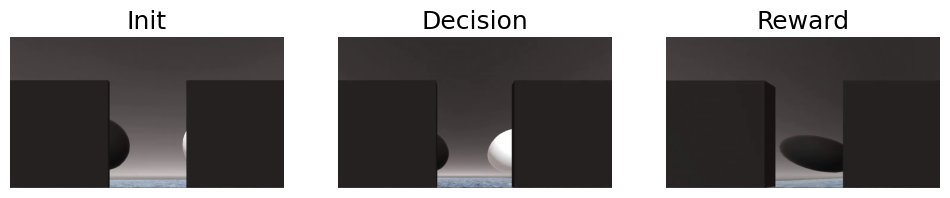

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(12, 6))
ax[0].imshow(ProcessedVideo().get_visual_frame({"dataset": "Pheasant_2024-08-15_2"}, 
                                               frame_index=4074))
ax[0].set_title(f"Init")
ax[1].imshow(ProcessedVideo().get_visual_frame({"dataset": "Pheasant_2024-08-15_2"}, 
                                               frame_index=4161))
ax[1].set_title(f"Decision")
ax[2].imshow(ProcessedVideo().get_visual_frame({"dataset": "Pheasant_2024-08-15_2"}, 
                                               frame_index=4248)) 
ax[2].set_title(f"Reward")


ax[0].axis("off")
ax[1].axis("off")
ax[2].axis("off")

fig.savefig("video_frames_dual_occluder_decision_points_trial5.svg", 
            bbox_inches="tight", dpi=300, transparent=True)

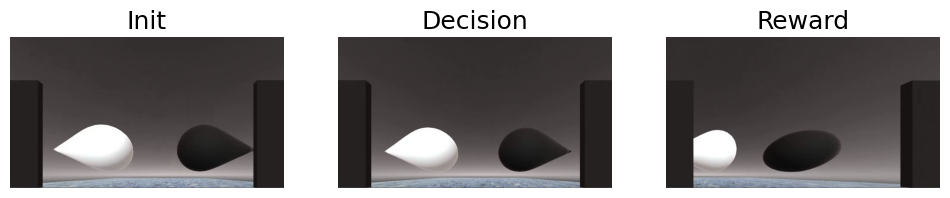

In [49]:


fig, ax = plt.subplots(1, 3, figsize=(12, 6))
ax[0].imshow(ProcessedVideo().get_visual_frame({"dataset": "Pheasant_2024-08-15_2"}, 
                                               frame_index=10339))
ax[0].set_title(f"Init")
ax[1].imshow(ProcessedVideo().get_visual_frame({"dataset": "Pheasant_2024-08-15_2"}, 
                                               frame_index=10366))
ax[1].set_title(f"Decision")
ax[2].imshow(ProcessedVideo().get_visual_frame({"dataset": "Pheasant_2024-08-15_2"}, 
                                               frame_index=10421)) 
ax[2].set_title(f"Reward")


ax[0].axis("off")
ax[1].axis("off")
ax[2].axis("off")

fig.savefig("video_frames_dual_occluder_decision_points_trial10.svg", 
            bbox_inches="tight", dpi=300, transparent=True)